# Downstream Analysis: CRG Identification, Alteration Type Disentanglement & CRR Delineation

This notebook performs three downstream analyses after SILPAG model training:

1. **Task 1: CRG Identification** — Identify condition-responsive genes.
2. **Task 2: Alteration Type Disentanglement** — Determine the nature of each CRG's alteration.
3. **Task 3: CRR Delineation** — Delineate condition-responsive tissue regions.

**Prerequisites:** A trained SILPAG model saved from `Getting Started with SILPAG`.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import torch
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

import SILPAG as sp

Matplotlib is building the font cache; this may take a moment.


## 1. Load Data & Preprocessing

Same preprocessing as `demo_test.ipynb` — load reference (normal breast) and target (breast cancer), intersect genes, filter.

In [3]:
ref = sc.read_h5ad('SILPAG/data/V02_nb.h5ad')
adata = sc.read_h5ad('SILPAG/data/H1_nb.h5ad')
ref.var_names_make_unique()
adata.var_names_make_unique()
sp.prefilter_specialgenes(ref)
sp.prefilter_specialgenes(adata)

gene = list(set(ref.var_names) & set(adata.var_names))
ref = ref[:, gene]
adata = adata[:, gene]

g1 = sc.pp.filter_genes(ref, min_cells=int(ref.shape[0] * 0.02), inplace=False)
g2 = sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.02), inplace=False)
ref = ref[:, g1[0] | g2[0]]
adata = adata[:, g1[0] | g2[0]]

key = list(set(ref.var_names) & set(adata.var_names))
ref = ref[:, key]
adata = adata[:, key]
ref.var['hkgene'] = adata.var['hkgene']

labels = np.zeros(ref.shape[1], dtype=int)
labels[np.where(ref.var['hkgene'] == 1)[0]] = 1
del ref.raw

print(f'Reference: {ref.shape}, Target: {adata.shape}')

Reference: (1896, 7874), Target: (613, 7874)


## 2. Load Trained Model & Generate View-Transferred SGMs

Load the saved model, compute the codebook transport plan, and generate:
- `result1`: view-transferred SGM (reference $\rightarrow$ target via OT)
- `result2`: target self-reconstruction

In [4]:
# Load saved config first so that patch_size, K, img_size etc. are restored
args = sp.Config.load_config('SILPAG/saved_model/hBC_demo')
args.device = 'cuda:7'
args.train = False

# Clear size lists — GeneDataset will re-populate them from the actual data
args.orig_img_size = []
args.resized_img_size = []
args.img_size = []

gene_images = [ref.varm['gene_img'], adata.varm['gene_img']]
train_dataset = sp.GeneDataset(gene_images, labels, args)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False, drop_last=False)
model, dataset, PI, Q = sp.train_marker(train_loader, hist_data=None, args=args)

print(f'Model loaded. Codebook sizes: {[model.get_codebook(i).shape[0] for i in range(args.num_slice)]}')

Shape of each View:  [(66, 96), (30, 30)]
Model loaded. Codebook sizes: [51, 203]


In [5]:
# Compute gene codes via OT transport plan
code = sp.get_code(model, dataset, hist_data=None, pi_init=PI, source_idx=0, target_idx=1, args=args)
adata.varm['code_ref'] = code[0]  # reference -> target (transported)
adata.varm['code_tgt'] = code[1]  # target native

# Generate SGMs
result1 = model.generate(args, adata, tgt_index=1, code_id='code_ref', gene='all')  # view-transferred
result2 = model.generate(args, adata, tgt_index=1, code_id='code_tgt', gene='all')  # target self-recon

print(f'Generated SGMs: {result1.shape}, {result2.shape}')

Generating...: 100%|██████████| 7874/7874 [00:07<00:00, 1018.05gene/s]


Generated SGMs: (613, 7874), (613, 7874)


# Task 1: CRG Identification

For each gene $i$, compute the CRG score:

$$S_i = \|\hat{\mathbf{x}}^{r \to t}_i - \mathbf{x}^t_i\|_F^2$$

The anchor gene scores form an empirical null modelled as $S \sim \Gamma(k, \theta)$. Genes with $p < 0.05$ are designated as CRGs.

In [6]:
# Compute CRG scores
scores = sp.compute_crg_scores(result1, adata)

# Anchor mask from training
anchor_mask = dataset.labels.astype(bool)
print(f'Total genes: {len(scores)}, Anchor genes: {anchor_mask.sum()}')

# Identify CRGs
# null_model='gamma': fits Gamma distribution to anchor scores
# No FDR correction — use raw p-value directly
crg_result = sp.identify_crgs(
    scores, anchor_mask,
    p_threshold=0.1,
    null_model='gamma',
    correction=None,
)

n_crg = crg_result['is_crg'].sum()
print(f'Identified {n_crg} CRGs (p < 0.05, null_model=gamma, no FDR)')
print(f'Null info: {crg_result["null_info"]}')

Total genes: 7874, Anchor genes: 1914
Identified 279 CRGs (p < 0.05, null_model=gamma, no FDR)
Null info: {'model': 'gamma', 'k': 0.4413334665723619, 'loc': 0, 'theta': np.float32(1823.2991)}


## Store CRG Results in AnnData

In [7]:
adata.var['crg_score'] = scores
adata.var['crg_pval'] = crg_result['pvalues']
adata.var['crg_fdr'] = crg_result['pvalues_adj']
adata.var['is_crg'] = crg_result['is_crg']

crg_genes = adata.var_names[crg_result['is_crg']]
print(f'Top 20 CRGs by score:')
adata.var.loc[crg_genes].sort_values('crg_score', ascending=False).head(20)[['crg_score', 'crg_fdr']]

Top 20 CRGs by score:


,crg_score,crg_fdr
IGLC3,112497.500000,0.000000e+00
IGHA1,111526.664062,0.000000e+00
IGHG3,107255.210938,0.000000e+00
RACK1,104407.476562,0.000000e+00
S100A9,99992.890625,0.000000e+00
IGHG4,95009.445312,0.000000e+00
IGKC,94801.414062,0.000000e+00
IGLC2,82554.914062,0.000000e+00
TMSB10,71694.773438,0.000000e+00
UBA52,61477.976562,1.110223e-16


# Task 2: Alteration Type Disentanglement

For each CRG, three statistical tests determine the nature of the alteration:

| Test | What it detects | Method |
|------|----------------|--------|
| Differential Abundance | Shift in expression magnitude | Wilcoxon rank-sum |
| Differential Prevalence | Change in fraction of expressing spots | Fisher's exact (binarised at $\epsilon$) |
| Differential Spatial Pattern | Structured spatial discrepancy | Moran's I permutation on SDM |

A gene can be assigned to multiple alteration types.

In [22]:
df_alt = sp.disentangle_alteration_types(
    result_ref=result1,
    adata=adata,
    crg_mask=crg_result['is_crg'],
    epsilon=0.01,              # binarisation threshold for prevalence
    n_neighbors=15,
    fdr_threshold=0.05,
    abundance_effect_size=1,
    spatial_I_threshold=0.1,   # require Moran's I >= 0.1 for spatial
)

print(f'Disentanglement results for {len(df_alt)} CRGs:')
print(df_alt[['is_diff_abundance', 'is_diff_prevalence', 'is_diff_spatial']].sum())

Disentanglement results for 279 CRGs:
is_diff_abundance     128
is_diff_prevalence    178
is_diff_spatial         0
dtype: int64


## Detailed Results Table

In [ ]:
# Merge CRG scores into the disentanglement table
df_alt['crg_score'] = adata.var.loc[df_alt.index, 'crg_score'].values
df_alt['crg_fdr'] = adata.var.loc[df_alt.index, 'crg_fdr'].values

df_display = df_alt.sort_values('crg_score', ascending=False)
df_display[['crg_score', 'crg_fdr', 'abundance_fdr', 'prevalence_fdr', 'spatial_fdr']].head(15)

,crg_score,crg_fdr,abundance_fdr,prevalence_fdr,spatial_fdr
gene,,,,,
IGLC3,112497.500000,0.000000e+00,0.000000e+00,1.0,0.279
IGHA1,111526.664062,0.000000e+00,0.000000e+00,1.0,0.279
IGHG3,107255.210938,0.000000e+00,0.000000e+00,1.0,0.279
RACK1,104407.476562,0.000000e+00,0.000000e+00,1.0,0.279
S100A9,99992.890625,0.000000e+00,0.000000e+00,1.0,0.279
IGHG4,95009.445312,0.000000e+00,0.000000e+00,1.0,0.279
IGKC,94801.414062,0.000000e+00,0.000000e+00,1.0,0.279
IGLC2,82554.914062,0.000000e+00,0.000000e+00,1.0,0.279
TMSB10,71694.773438,0.000000e+00,0.000000e+00,1.0,0.279


## Example CRG Visualisation

Visualise the reference expression, view-transferred SGM, target self-reconstruction, and SDM.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Ari

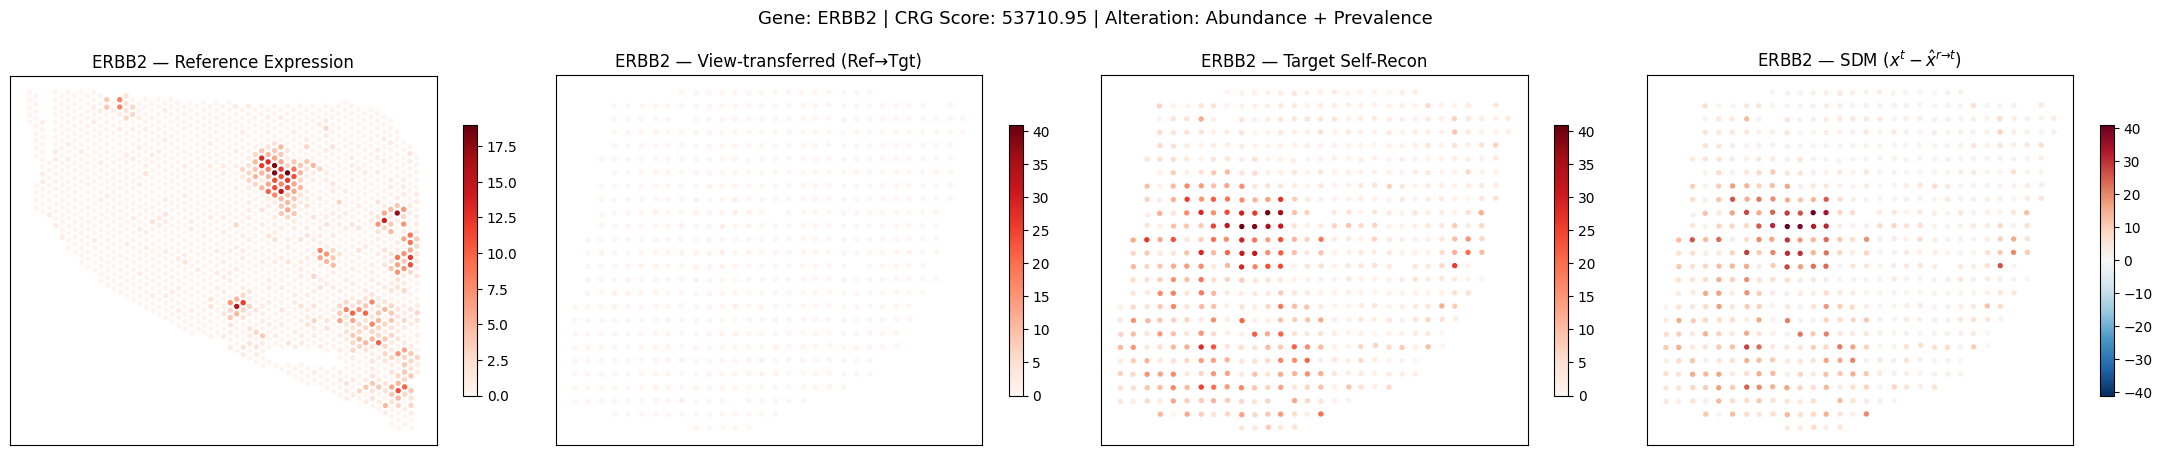

In [ ]:
# Visualise
top_gene = 'S100A8'
gene_idx = list(adata.var_names).index(top_gene)

X_ref_sgm = result1.X.toarray() if sparse.issparse(result1.X) else np.array(result1.X)

# Reference slice: original expression on reference coordinates
ref_expr = ref.X.toarray()[:, gene_idx] if sparse.issparse(ref.X) else np.array(ref.X)[:, gene_idx]
ref_coords = ref.obsm['spatial']

# Target slice
tgt_coords = adata.obsm['spatial']
expr_vt = X_ref_sgm[:, gene_idx]      # view-transferred

# Original target expression
tgt_raw = adata.X.toarray()[:, gene_idx] if sparse.issparse(adata.X) else np.array(adata.X)[:, gene_idx]

# Normalize (library-size) + log1p before visualisation
def _norm_log(x):
    total = x.sum()
    if total > 0:
        x = x / total * np.median([ref_expr.sum(), expr_vt.sum(), tgt_raw.sum()])
    return np.log1p(x)

ref_expr = _norm_log(ref_expr)
expr_vt  = _norm_log(expr_vt)
tgt_raw  = _norm_log(tgt_raw)

sdm = tgt_raw - expr_vt               # SDM: original target - view-transferred

fig, axes = plt.subplots(1, 4, figsize=(22, 4.5))

# Unified color scale for expression panels
vmin_expr = 0
vmax_expr = max(ref_expr.max(), expr_vt.max(), tgt_raw.max())

# Panel 0: Reference expression (on reference coordinates)
sc0 = axes[0].scatter(ref_coords[:, 0], ref_coords[:, 1], c=ref_expr, s=8, cmap='Reds', vmin=vmin_expr, vmax=vmax_expr)
axes[0].set_title(f'{top_gene} — Reference Expression')
axes[0].set_aspect('equal')
axes[0].invert_yaxis()
plt.colorbar(sc0, ax=axes[0], shrink=0.7)

# Panel 1: View-transferred SGM (on target coordinates)
sc1 = axes[1].scatter(tgt_coords[:, 0], tgt_coords[:, 1], c=expr_vt, s=8, cmap='Reds', vmin=vmin_expr, vmax=vmax_expr)
axes[1].set_title(f'{top_gene} — View-transferred (Ref→Tgt)')
axes[1].set_aspect('equal')
axes[1].invert_yaxis()
plt.colorbar(sc1, ax=axes[1], shrink=0.7)

# Panel 2: Original target expression (on target coordinates)
sc2 = axes[2].scatter(tgt_coords[:, 0], tgt_coords[:, 1], c=tgt_raw, s=8, cmap='Reds', vmin=vmin_expr, vmax=vmax_expr)
axes[2].set_title(f'{top_gene} — Original Target Expression')
axes[2].set_aspect('equal')
axes[2].invert_yaxis()
plt.colorbar(sc2, ax=axes[2], shrink=0.7)

# Panel 3: SDM (symmetric scale)
vlim = max(abs(sdm.min()), abs(sdm.max()))
sc3 = axes[3].scatter(tgt_coords[:, 0], tgt_coords[:, 1], c=sdm, s=8, cmap='RdBu_r', vmin=-vlim, vmax=vlim)
axes[3].set_title(f'{top_gene} — SDM ($x^t - \\hat{{x}}^{{r→t}}$)')
axes[3].set_aspect('equal')
axes[3].invert_yaxis()
plt.colorbar(sc3, ax=axes[3], shrink=0.7)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

if top_gene in df_alt.index:
    alt_type = df_alt.loc[top_gene, 'alteration_type']
else:
    alt_type = 'N/A'
fig.suptitle(f'Gene: {top_gene} | CRG Score: {scores[gene_idx]:.2f} | Alteration: {alt_type}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Task 3: CRR Delineation

Delineate condition-responsive tissue regions (CRR) using two approaches:

- **Marker-based**: For a known condition-associated gene $g$, compute the SDM $D_g = |\hat{\mathbf{x}}^{r \to t}_g - \mathbf{x}^t_g|$, smooth with a Gaussian kernel ($\sigma=1$), then apply Otsu's method to find the optimal threshold $\tau^*$ that maximises between-group variance.
- **Marker-free**: When no markers are available, use all CRGs. Each spot $i$ gets a discrepancy vector $\mathbf{f}_i \in \mathbb{R}^{|I_{CRG}|}$. Leiden clustering on $\{\mathbf{f}_i\}$ yields two spatial domains; the CRR is the one with higher aggregate discrepancy.

## Marker-based CRR Delineation

Use ERBB2 as the marker gene to delineate the CRR.

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

Marker gene for CRR delineation: ERBB2
CRR spots: 100/613 (Otsu threshold: 1.86)


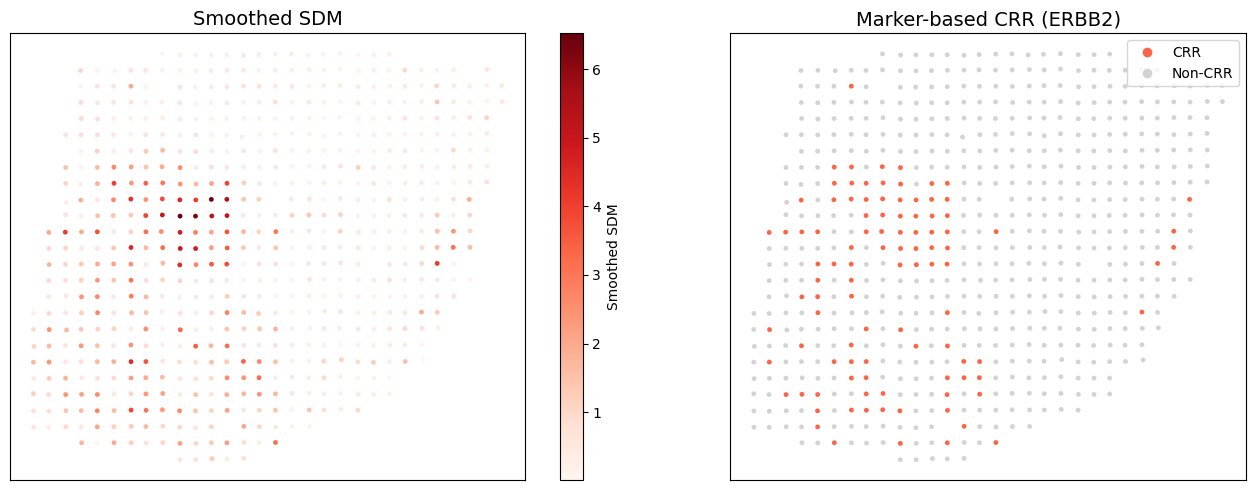

In [12]:
# Marker-based delineation with ERBB2
marker_gene = 'ERBB2'
print(f'Marker gene for CRR delineation: {marker_gene}')

crr_marker = sp.delineate_crr_marker(
    result_ref=result1,
    adata=adata,
    gene=marker_gene,
    sigma=1.0,
)

n_crr = crr_marker['crr_mask'].sum()
print(f'CRR spots: {n_crr}/{len(crr_marker["crr_mask"])} '
      f'(Otsu threshold: {crr_marker["threshold"]:.2f})')

# Visualise
sp.plot_crr(
    coords=crr_marker['coords'],
    crr_mask=crr_marker['crr_mask'],
    sdm_smoothed=crr_marker['sdm_smoothed'],
    title=f'Marker-based CRR ({marker_gene})',
)

## Store CRR Results

In [ ]:
# Store CRR annotations in adata.obs
adata.obs['crr_marker'] = crr_marker['crr_mask'].astype(int)
adata.obs['crr_marker_sdm'] = crr_marker['sdm_smoothed']

print(f'Marker-based CRR: {adata.obs["crr_marker"].sum()} spots')

Marker-based CRR: 100 spots
Marker-free CRR:  77 spots


# Save All Results

In [32]:
# Save disentanglement table
df_alt.to_csv('crg_disentanglement_results.csv')

# Save full gene-level results
adata.var[['crg_score', 'crg_pval', 'crg_fdr', 'is_crg']].to_csv('crg_identification_results.csv')

# Save GO enrichment results
# df_pathway.to_csv('crg_pathway_enrichment_results.csv', index=False)

# Save CRR results
adata.obs[['crr_marker', 'crr_marker_sdm']].to_csv('crr_delineation_results.csv')

print('All results saved.')

KeyError: "None of [Index(['crr_marker', 'crr_marker_sdm'], dtype='object')] are in the [columns]"